# Perfilado de Datos — Cruz Azul F.C. Intelligence
**Materia:** Calidad y Preprocesamiento de Datos  
**Framework:** DAMA-DMBOK  
**Etapa:** I — Perfilado (antes y después de limpieza)  

Este notebook realiza el perfilado de las 4 fuentes de datos utilizadas en el proyecto:
1. **LigaMX** — Partidos 2016-2024 (formato JSON)
2. **Transfermarkt** — Jugadores (formato XLSX)
3. **FIFA 23** — Entrenadores masculinos (formato TXT)
4. **OpenPublicDomainFootballData** — Partidos históricos Liga MX (formato CSV)

---
### Dimensiones DAMA-DMBOK evaluadas:
| Dimensión | Qué medimos |
|---|---|
| Completitud | % de valores nulos por columna |
| Unicidad | % de registros duplicados |
| Validez | Tipos de dato, patrones, rangos |
| Consistencia | Formatos heterogéneos entre fuentes |

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Estilo de graficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')
COLORES = ['#003DA5', '#C8102E', '#FFFFFF', '#888888']  # Paleta Cruz Azul :)


# Rutas base
BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW = os.path.join(BASE, 'Datos_originales')
MOD = os.path.join(BASE, 'Datos_modificados')
REPORTS = os.path.join(BASE, 'reports')
os.makedirs(REPORTS, exist_ok=True)

print('Rutas configuradas:')
print(f'  BASE    : {BASE}')
print(f'  MOD     : {MOD}')
print(f'  REPORTS : {REPORTS}')

Rutas configuradas:
  BASE    : /Users/milenafer/Desktop/claude/Calidad_PFinal
  MOD     : /Users/milenafer/Desktop/claude/Calidad_PFinal/Datos_modificados
  REPORTS : /Users/milenafer/Desktop/claude/Calidad_PFinal/reports


---
## 1. Carga de datos desde múltiples formatos

Las 4 fuentes se encuentran en formatos distintos (**JSON, XLSX, TXT, CSV**), lo que refleja la heterogeneidad real de los sistemas de información deportiva.

In [3]:
# Fuente 1: LigaMX → JSON 
ruta_ligamx = os.path.join(MOD, 'LigaMX', '2016-2024_liga_mx.json')
df_ligamx = pd.read_json(ruta_ligamx)
print(f'LigaMX cargado desde JSON: {df_ligamx.shape[0]:,} filas x {df_ligamx.shape[1]} columnas')

# Fuente 2: Transfermarkt players → XLSX 
ruta_tm = os.path.join(MOD, 'FootballDatafromTransfermarkt', 'players.xlsx')
df_tm = pd.read_excel(ruta_tm, engine='openpyxl')
print(f'Transfermarkt cargado desde XLSX: {df_tm.shape[0]:,} filas x {df_tm.shape[1]} columnas')

# Fuente 3: FIFA 23 male_coaches → TXT (tab-separated) 
ruta_fifa = os.path.join(MOD, 'FIFA23complete_player_dataset', 'male_coaches.txt')
df_fifa = pd.read_csv(ruta_fifa, sep='\t', low_memory=False)
print(f'FIFA23 cargado desde TXT: {df_fifa.shape[0]:,} filas x {df_fifa.shape[1]} columnas')

# Fuente 4: OpenPublicDomain (todos los mx.1.csv de cada temporada) 
archivos_mx = sorted(glob.glob(os.path.join(RAW, 'OpenPublicDomainFootballData', '*', 'mx.1.csv')))
df_opfd = pd.concat([pd.read_csv(f) for f in archivos_mx], ignore_index=True)
print(f'OpenPublicDomain cargado desde CSV ({len(archivos_mx)} temporadas): {df_opfd.shape[0]:,} filas x {df_opfd.shape[1]} columnas')

LigaMX cargado desde JSON: 2,876 filas x 23 columnas
Transfermarkt cargado desde XLSX: 47,669 filas x 26 columnas
FIFA23 cargado desde TXT: 1,155 filas x 8 columnas
OpenPublicDomain cargado desde CSV (7 temporadas): 2,191 filas x 13 columnas


---
## 2. Función auxiliar de perfilado

Centralizamos las métricas de calidad en una función reutilizable alineada con las dimensiones DAMA-DMBOK.

In [24]:
def perfil_basico(df, nombre_fuente):
    """perfil_basico
    Imprime un resumen de calidad de un DataFrame: dimensiones, nulos,
    duplicados, tipos de dato y las primeras 3 filas.
    ---
    params:
        df: pd.DataFrame — Dataset a perfilar.
        nombre_fuente : str — Nombre descriptivo de la fuente (se usa en el 
        encabezado).
    ---
    return:
        None — Imprime el resumen en consola y muestra df.head(3) con display().
    """
    total_celdas = df.shape[0] * df.shape[1]
    nulos_total  = df.isnull().sum().sum()
    duplicados   = df.duplicated().sum()

    print(f'\n{'*-'*30}')
    print(f'  FUENTE: {nombre_fuente}')
    print(f'{'*-'*30}')
    print(f'  Filas              : {df.shape[0]:>10,}')
    print(f'  Columnas           : {df.shape[1]:>10}')
    print(f'  Celdas totales     : {total_celdas:>10,}')
    print(f'  Celdas nulas       : {nulos_total:>10,}  ({nulos_total/total_celdas*100:.1f}%)')
    print(f'  Filas duplicadas   : {duplicados:>10,}  ({duplicados/df.shape[0]*100:.1f}%)')
    print(f'\n  Tipos de dato:')
    for dtype, count in df.dtypes.value_counts().items():
        print(f'    {str(dtype):<12}: {count} columna(s)')
    print()
    display(df.head(3))


def grafica_nulos(df, titulo, color='#003DA5'):
    """grafica_nulos
    Genera una grafica de barras horizontal con el porcentaje de valores
    nulos por columna. Las barras superan el 50% se colorean en rojo (#C8102E).
    Si el DataFrame no tiene nulos, imprime un mensaje y no genera grafica.
    ---
    params:
        df: pd.DataFrame — Dataset a analizar.
        titulo : str — Titulo que aparece en la grafica y en el mensaje de sin nulos.
        color  : str — Color hexadecimal para barras bajo el 50% (default: azul Cruz Azul).
    ---
    return:
        None — Muestra la grafica con plt.show().
    """
    nulos_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    nulos_pct = nulos_pct[nulos_pct > 0]  # Solo columnas con nulos
    if nulos_pct.empty:
        print(f'  [{titulo}] Sin valores nulos.')
        return
    colores_bar = ['#C8102E' if v > 50 else color for v in nulos_pct.values]
    fig, ax = plt.subplots(figsize=(10, max(3, len(nulos_pct)*0.4)))
    bars = ax.barh(nulos_pct.index, nulos_pct.values, color=colores_bar)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 105)
    for bar, val in zip(bars, nulos_pct.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Porcentaje de Valores Nulos — {titulo}', fontweight='bold')
    ax.set_xlabel('% de nulos')
    plt.tight_layout()
    plt.show()


def grafica_tipos(df, titulo):
    """grafica_tipos
    Genera un pie chart con la distribucion de tipos de dato (int64, float64,
    object, etc.) presentes en las columnas del DataFrame.
    ---
    params:
        df: pd.DataFrame — Dataset a analizar.
        titulo : str — Titulo que aparece en la gráfica.
    ---
    return:
        None — Muestra la grafica con plt.show().
    """
    conteo = df.dtypes.astype(str).value_counts()
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.pie(conteo.values, labels=conteo.index, autopct='%1.0f%%',
           colors=COLORES[:len(conteo)], startangle=90)
    ax.set_title(f'Tipos de dato — {titulo}', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 3. Perfilado — Fuente 1: LigaMX (JSON)

**Dataset:** Partidos de la Liga MX 2016–2024  
**Problemática relacionada:** #4 — Inconsistencia en nombres de equipos entre temporadas  

In [25]:
perfil_basico(df_ligamx, 'LigaMX 2016-2024')


*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  FUENTE: LigaMX 2016-2024
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  Filas              :      2,876
  Columnas           :         23
  Celdas totales     :     66,148
  Celdas nulas       :     14,794  (22.4%)
  Filas duplicadas   :          0  (0.0%)

  Tipos de dato:
    float64     : 13 columna(s)
    object      : 7 columna(s)
    int64       : 2 columna(s)
    datetime64[ns, UTC]: 1 columna(s)



,id,referee,timezone,date,venue_id,venue_name,venue_city,season,round,home_team,...,home_goals,away_goals,home_goals_half_time,away_goals_half_time,home_goals_fulltime,away_goals_fulltime,home_goals_extra_time,away_goals_extratime,home_goals_penalty,away_goals_penalty
0,864095,D. Quintero,UTC,2022-07-02 02:05:00+00:00,10546.0,Estadio de Mazatlán,Mazatlán,2022,Apertura - 1,Mazatlán,...,2.0,4.0,0.0,2.0,2.0,4.0,NaN,NaN,NaN,NaN
1,864096,I. Lopez,UTC,2022-07-02 22:00:00+00:00,1076.0,Estadio AKRON,Zapopan,2022,Apertura - 1,Guadalajara Chivas,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,864094,L. Santander,UTC,2022-07-02 22:00:00+00:00,1080.0,Estadio Victoria de Aguascalientes,Aguascalientes,2022,Apertura - 1,Necaxa,...,1.0,3.0,1.0,2.0,1.0,3.0,NaN,NaN,NaN,NaN


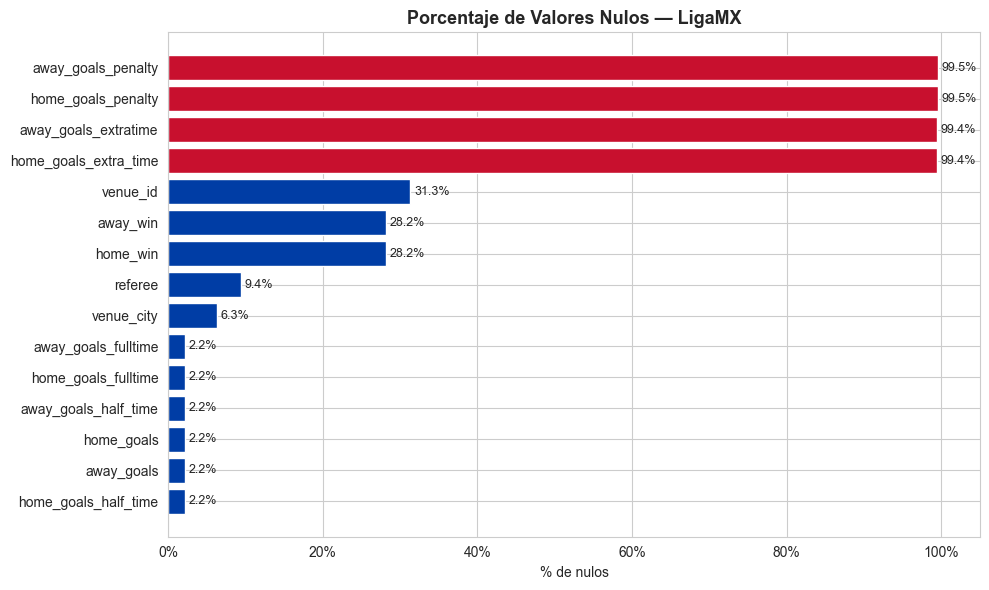

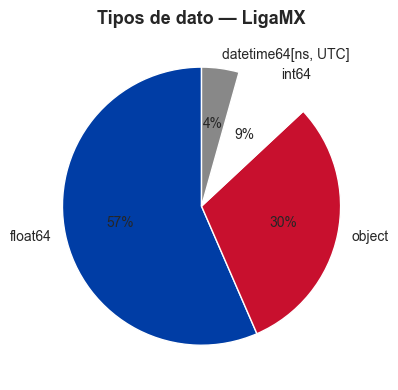

In [26]:
grafica_nulos(df_ligamx, 'LigaMX')
grafica_tipos(df_ligamx, 'LigaMX')

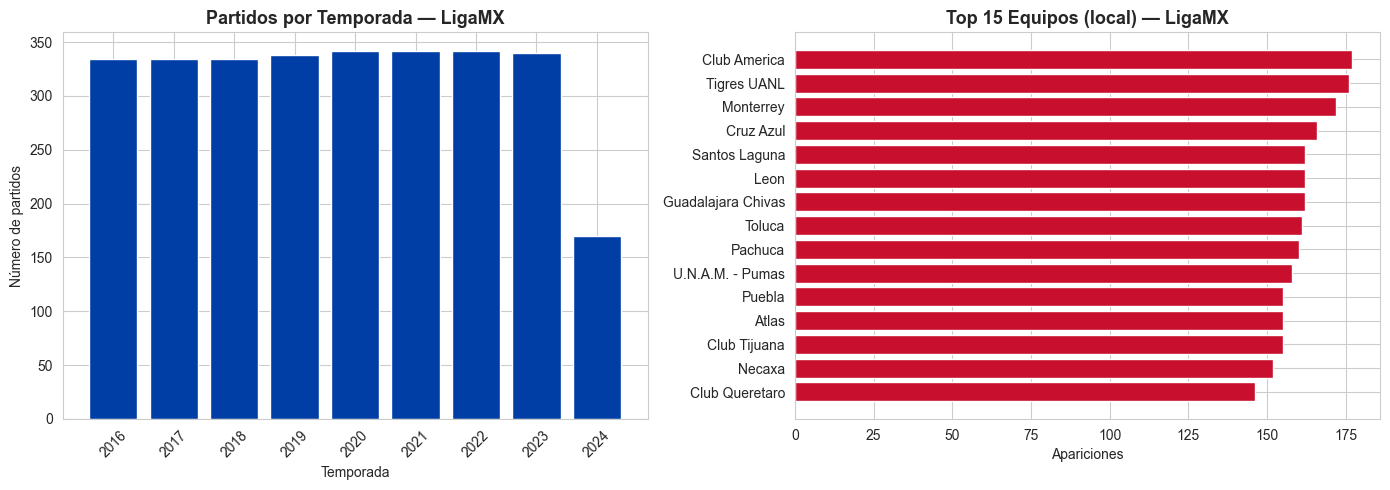


Alerta de calidad — Consistencia (Problemática #4):
  Equipos únicos detectados en columna "home_team": 23
  Liga MX tiene 18 equipos activos — valores mayores sugieren inconsistencias de nombres.

  Muestra de nombres únicos:
['Mazatlán' 'Guadalajara Chivas' 'Necaxa' 'Tigres UANL' 'Club America'
 'U.N.A.M. - Pumas' 'Atletico San Luis' 'Santos Laguna' 'Pachuca'
 'Club Tijuana' 'Puebla' 'Leon' 'Monterrey' 'Cruz Azul' 'Toluca'
 'Club Queretaro' 'FC Juarez' 'Atlas' 'León' 'Monarcas']


In [29]:
# Distribucion de partidos por temporada
col_temporada = 'season' if 'season' in df_ligamx.columns else df_ligamx.columns[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo_temp = df_ligamx[col_temporada].value_counts().sort_index()
axes[0].bar(conteo_temp.index.astype(str), conteo_temp.values, color='#003DA5')
axes[0].set_title('Partidos por Temporada — LigaMX', fontweight='bold')
axes[0].set_xlabel('Temporada')
axes[0].set_ylabel('Número de partidos')
axes[0].tick_params(axis='x', rotation=45)

# Equipos con mas apariciones (deteccion de inconsistencia en nombres)
col_home = [c for c in df_ligamx.columns if 'home' in c.lower() or 'local' in c.lower()][0]
top_equipos = df_ligamx[col_home].value_counts().head(15)
axes[1].barh(top_equipos.index[::-1], top_equipos.values[::-1], color='#C8102E')
axes[1].set_title('Top 15 Equipos (local) — LigaMX', fontweight='bold')
axes[1].set_xlabel('Apariciones')

plt.tight_layout()
plt.show()

# Alerta: equipos unicos (posibles inconsistencias de nombres)
n_equipos = df_ligamx[col_home].nunique()
print(f'\nAlerta de calidad — Consistencia (Problemática #4):')
print(f'  Equipos únicos detectados en columna "{col_home}": {n_equipos}')
print(f'  Liga MX tiene 18 equipos activos — valores mayores sugieren inconsistencias de nombres.')
print(f'\n  Muestra de nombres únicos:')
print(df_ligamx[col_home].unique()[:20])

---
## 4. Perfilado — Fuente 2: Transfermarkt players (XLSX)

**Dataset:** Jugadores con valor de mercado y estadísticas reales  
**Problemáticas relacionadas:** #2 (valores faltantes/desactualizados), #3 (jugadores duplicados)

In [28]:
perfil_basico(df_tm, 'Transfermarkt — Players')


*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  FUENTE: Transfermarkt — Players
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  Filas              :     47,669
  Columnas           :         26
  Celdas totales     :  1,239,394
  Celdas nulas       :    183,816  (14.8%)
  Filas duplicadas   :          0  (0.0%)

  Tipos de dato:
    object      : 17 columna(s)
    float64     : 6 columna(s)
    int64       : 3 columna(s)



,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


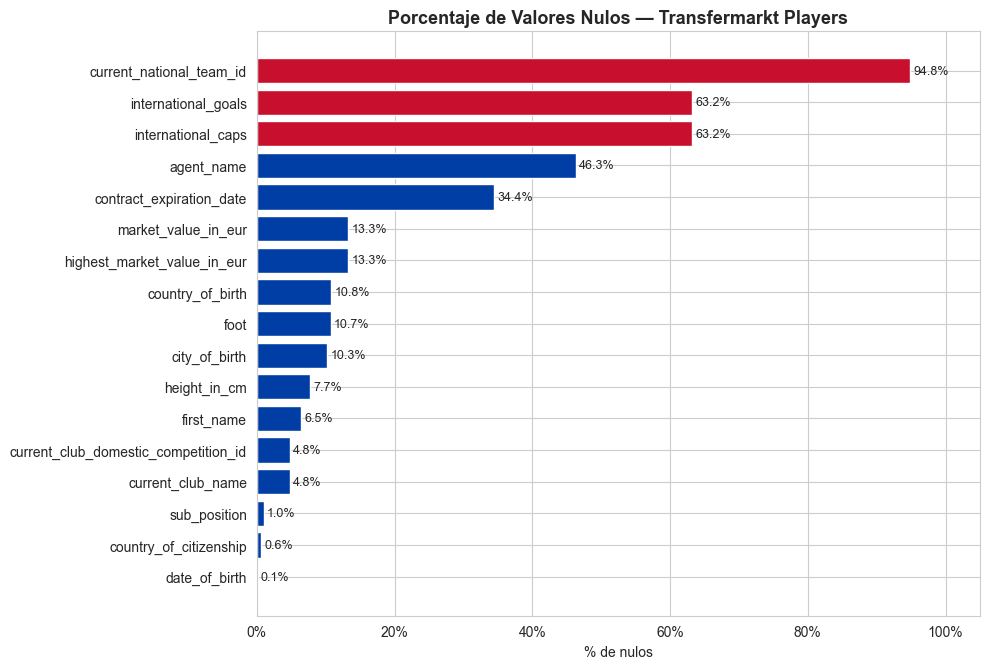

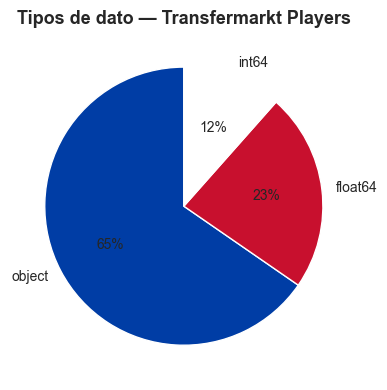

In [9]:
grafica_nulos(df_tm, 'Transfermarkt Players')
grafica_tipos(df_tm, 'Transfermarkt Players')

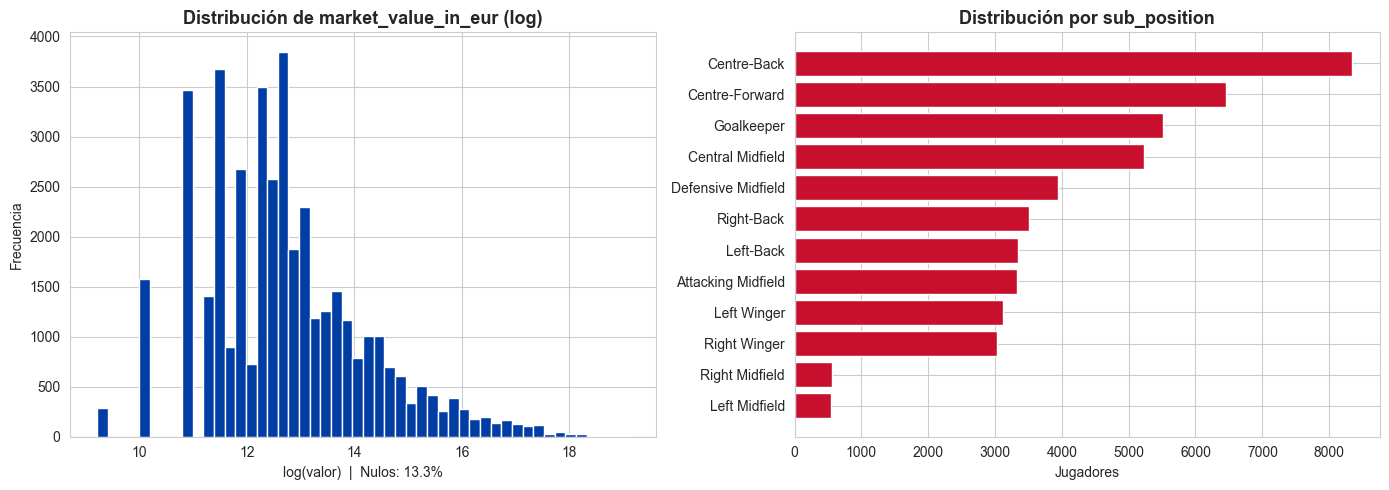


Alerta de calidad — Unicidad (Problemática #3):
  Columnas de nacionalidad detectadas: ['country_of_birth', 'country_of_citizenship', 'international_caps', 'international_goals', 'current_national_team_id']
  Valores únicos en "country_of_birth": 202
  Valores únicos en "country_of_citizenship": 198


In [30]:
# Analisis de valor de mercado
col_valor = [c for c in df_tm.columns if 'market' in c.lower() or 'value' in c.lower() or 'market_value' in c.lower()]
col_pos = [c for c in df_tm.columns if 'posit' in c.lower() or 'sub_position' in c.lower()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if col_valor:
    col_v = col_valor[0]
    valores = df_tm[col_v].dropna()
    axes[0].hist(np.log1p(valores), bins=50, color='#003DA5', edgecolor='white')
    axes[0].set_title(f'Distribución de {col_v} (log)', fontweight='bold')
    axes[0].set_xlabel('log(1 + valor de mercado)')
    axes[0].set_ylabel('Frecuencia')
    pct_nulos_valor = df_tm[col_v].isnull().mean() * 100
    axes[0].set_xlabel(f'log(valor)  |  Nulos: {pct_nulos_valor:.1f}%')
else:
    axes[0].text(0.5, 0.5, 'Columna de valor no encontrada', ha='center', transform=axes[0].transAxes)

if col_pos:
    col_p = col_pos[0]
    top_pos = df_tm[col_p].value_counts().head(12)
    axes[1].barh(top_pos.index[::-1], top_pos.values[::-1], color='#C8102E')
    axes[1].set_title(f'Distribución por {col_p}', fontweight='bold')
    axes[1].set_xlabel('Jugadores')
else:
    axes[1].text(0.5, 0.5, 'Columna de posición no encontrada', ha='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

# Alerta de calidad: jugadores con multiples nacionalidades (Problematica #3)
col_nac = [c for c in df_tm.columns if 'nation' in c.lower() or 'country' in c.lower()]
if col_nac:
    print(f'\nAlerta de calidad — Unicidad (Problemática #3):')
    print(f'  Columnas de nacionalidad detectadas: {col_nac}')
    for c in col_nac[:2]:
        print(f'  Valores únicos en "{c}": {df_tm[c].nunique()}')

---
## 5. Perfilado — Fuente 3: FIFA 23 male_coaches (TXT)

**Dataset:** Entrenadores masculinos FIFA 23  
**Problemática relacionada:** #1 (inconsistencia en nombres), #5 (métricas incomparables)

In [31]:
perfil_basico(df_fifa, 'FIFA 23 — Male Coaches')


*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  FUENTE: FIFA 23 — Male Coaches
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  Filas              :      1,155
  Columnas           :          8
  Celdas totales     :      9,240
  Celdas nulas       :        888  (9.6%)
  Filas duplicadas   :          0  (0.0%)

  Tipos de dato:
    object      : 6 columna(s)
    int64       : 2 columna(s)



,coach_id,coach_url,short_name,long_name,dob,nationality_id,nationality_name,face_url
0,24,/coach/24/david-unsworth/,D. Unsworth,David Unsworth,1973-10-16,14,England,NaN
1,50,/coach/50/steven-gerrard/,S. Gerrard,Steven Gerrard,1980-05-30,14,England,https://cdn.sportmonks.com/images/soccer/playe...
2,95,/coach/95/frank-lampard/,F. Lampard,Frank Lampard,1978-06-20,14,England,https://cdn.sportmonks.com/images/soccer/playe...


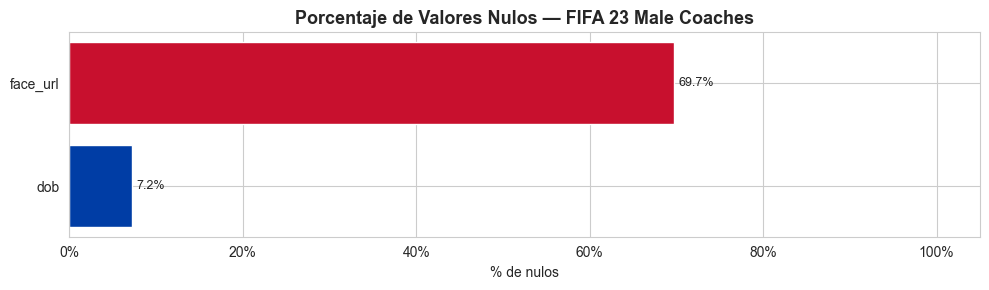

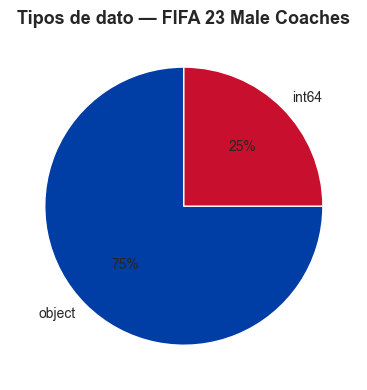

In [32]:
grafica_nulos(df_fifa, 'FIFA 23 Male Coaches')
grafica_tipos(df_fifa, 'FIFA 23 Male Coaches')

Columnas numéricas en FIFA23 male_coaches: ['coach_id', 'nationality_id']


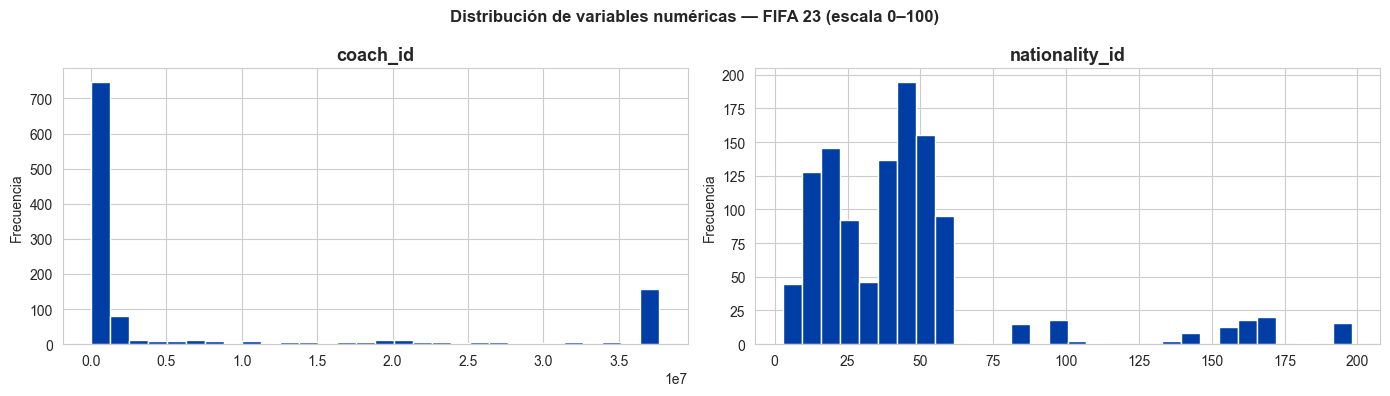

,coach_id,nationality_id
count,1.155000e+03,1155.000000
mean,7.843002e+06,45.825974
std,1.348492e+07,37.476856
min,2.400000e+01,3.000000
25%,2.536485e+05,21.000000
50%,5.137780e+05,39.000000
75%,6.972814e+06,52.000000
max,3.766662e+07,198.000000


In [33]:
# Analisis de rangos numericos (escala 0-100 FIFA — Problematica #5)
cols_num = df_fifa.select_dtypes(include=[np.number]).columns.tolist()
print(f'Columnas numéricas en FIFA23 male_coaches: {cols_num}')

if cols_num:
    fig, axes = plt.subplots(1, min(len(cols_num), 3), figsize=(14, 4))
    if len(cols_num) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_num[:3]):
        df_fifa[col].dropna().hist(bins=30, ax=ax, color='#003DA5', edgecolor='white')
        ax.set_title(col, fontweight='bold')
        ax.set_ylabel('Frecuencia')
    plt.suptitle('Distribución de variables numéricas — FIFA 23 (escala 0–100)', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Estadisticas descriptivas
display(df_fifa.describe())

---
## 6. Perfilado — Fuente 4: OpenPublicDomainFootballData (CSV)

**Dataset:** Partidos históricos Liga MX desde múltiples temporadas  
**Problemática relacionada:** #4 (cambios de nombre de equipos: Monarcas → Mazatlán)

In [34]:
perfil_basico(df_opfd, 'OpenPublicDomain — Liga MX')


*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  FUENTE: OpenPublicDomain — Liga MX
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
  Filas              :      2,191
  Columnas           :         13
  Celdas totales     :     28,483
  Celdas nulas       :      6,903  (24.2%)
  Filas duplicadas   :          0  (0.0%)

  Tipos de dato:
    object      : 13 columna(s)



,Stage,Round,Date,Time,Timezone,Team 1,FT,HT,Team 2,UTC,ET,P,Comments
0,Apertura,1,Fri Jul 20 2018,21:00,CDT/-0500,Atlas Guadalajara,0-0,0-0,Gallos Blancos,2018-07-21T02:00Z,NaN,NaN,NaN
1,Apertura,1,Fri Jul 20 2018,19:00,CDT/-0500,CD Veracruz,0-2,0-2,Pumas UNAM,2018-07-21T00:00Z,NaN,NaN,NaN
2,Apertura,1,Sat Jul 21 2018,17:00,CDT/-0500,Cruz Azul,3-0,0-0,Puebla FC,2018-07-21T22:00Z,NaN,NaN,NaN


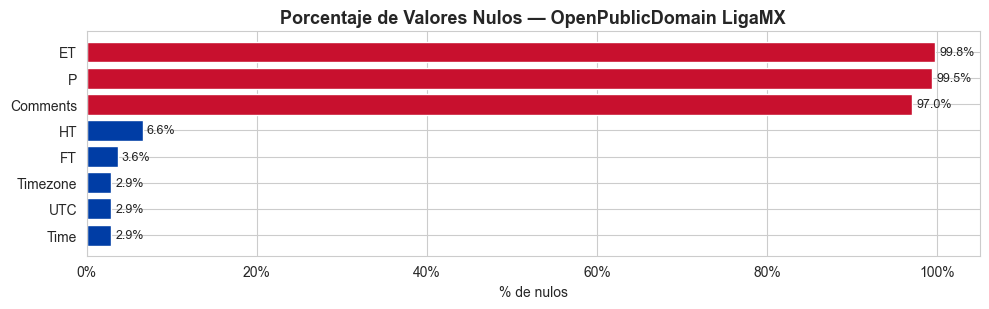

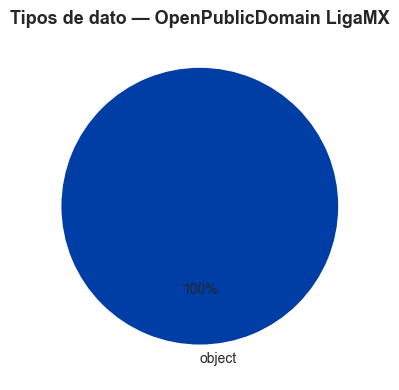

In [35]:
grafica_nulos(df_opfd, 'OpenPublicDomain LigaMX')
grafica_tipos(df_opfd, 'OpenPublicDomain LigaMX')

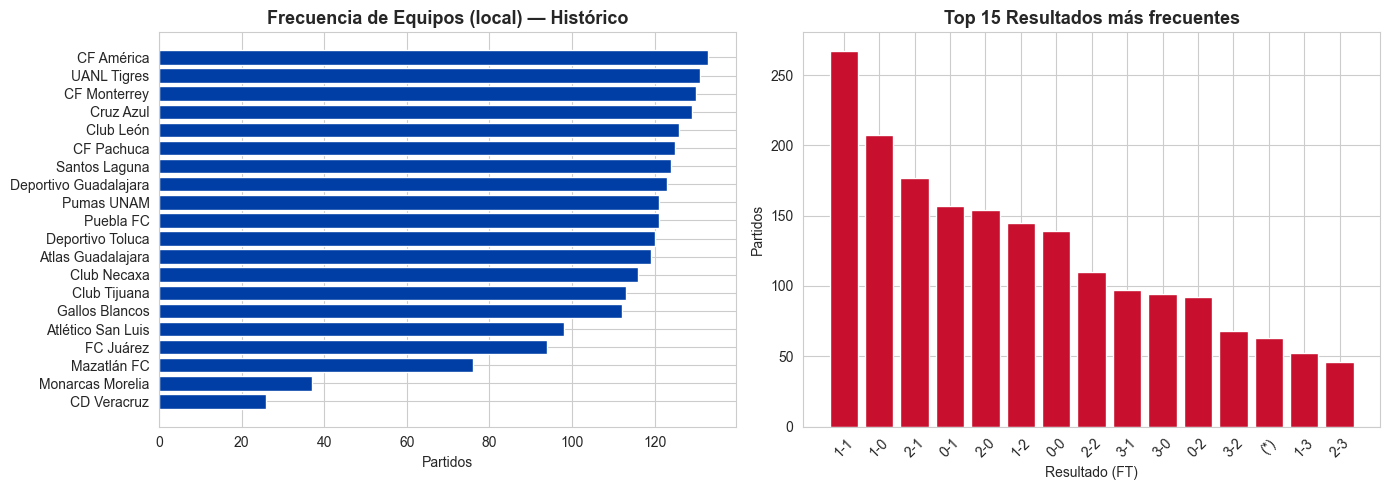


Alerta de calidad — Consistencia (Problemática #4):
  Equipos únicos en histórico: 21
  Equipos esperados (~18 activos + históricos): ~25-30


In [36]:
# Analisis de resultados y equipos
col_t1 = [c for c in df_opfd.columns if 'team' in c.lower() or 'home' in c.lower() or 'Team 1' in c][0]
col_ft = [c for c in df_opfd.columns if 'ft' in c.lower() or 'score' in c.lower() or 'FT' in c][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equipos unicos (cambios de nombre a lo largo de temporadas)
top_equipos_opfd = df_opfd[col_t1].value_counts().head(20)
axes[0].barh(top_equipos_opfd.index[::-1], top_equipos_opfd.values[::-1], color='#003DA5')
axes[0].set_title('Frecuencia de Equipos (local) — Histórico', fontweight='bold')
axes[0].set_xlabel('Partidos')

# Distribucion de resultados
resultados = df_opfd[col_ft].value_counts().head(15)
axes[1].bar(resultados.index.astype(str), resultados.values, color='#C8102E')
axes[1].set_title('Top 15 Resultados más frecuentes', fontweight='bold')
axes[1].set_xlabel('Resultado (FT)')
axes[1].set_ylabel('Partidos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Alerta: numero de equipos unicos vs. temporadas (detectar cambios de nombre)
n_eq = df_opfd[col_t1].nunique()
print(f'\nAlerta de calidad — Consistencia (Problemática #4):')
print(f'  Equipos únicos en histórico: {n_eq}')
print(f'  Equipos esperados (~18 activos + históricos): ~25-30')
if n_eq > 30:
    print(f'  ALERTA: {n_eq} nombres únicos sugieren inconsistencias (ej. Monarcas Morelia vs Mazatlán FC)')

---
## 7. Resumen Comparativo de Calidad

Tabla consolidada de métricas de calidad por fuente, siguiendo el framework DAMA-DMBOK.

In [37]:
def metricas_calidad(df, nombre, formato):
    """metricas_calidad
    Calcula metricas de calidad de un DataFrame y las devuelve como
    diccionario listo para construir una tabla comparativa entre fuentes.
    ---
    params:
        df : pd.DataFrame — Dataset a evaluar.
        nombre  : str — Nombre descriptivo de la fuente de datos.
        formato : str — Formato original del archivo (ej. 'CSV', 'JSON', 'XLSX','TXT').
    ---
    return:
        dict — Diccionario con las claves: Fuente, Formato, Filas, Columnas,
               Nulos (%), Duplicados (%), Cols numéricas, Cols texto.
    """
    total_celdas = df.shape[0] * df.shape[1]
    return {
        'Fuente'          : nombre,
        'Formato'         : formato,
        'Filas'           : df.shape[0],
        'Columnas'        : df.shape[1],
        'Nulos (%)'       : round(df.isnull().sum().sum() / total_celdas * 100, 2),
        'Duplicados (%)'  : round(df.duplicated().sum() / df.shape[0] * 100, 2),
        'Cols numéricas'  : df.select_dtypes(include=np.number).shape[1],
        'Cols texto'      : df.select_dtypes(include='object').shape[1]}

resumen = pd.DataFrame([
    metricas_calidad(df_ligamx, 'LigaMX 2016-2024',  'JSON'),
    metricas_calidad(df_tm,     'Transfermarkt',     'XLSX'),
    metricas_calidad(df_fifa,   'FIFA23 coaches',    'TXT'),
    metricas_calidad(df_opfd,   'OpenPublicDomain',  'CSV')])

# Formato visual
display(resumen.style
    .background_gradient(subset=['Nulos (%)'],     cmap='RdYlGn_r', vmin=0, vmax=100)
    .background_gradient(subset=['Duplicados (%)'], cmap='RdYlGn_r', vmin=0, vmax=20)
    .set_caption('Resumen de Calidad de Datos por Fuente — Framework DAMA-DMBOK')
    .format({'Filas': '{:,}', 'Nulos (%)': '{:.1f}%', 'Duplicados (%)': '{:.1f}%'}))

,Fuente,Formato,Filas,Columnas,Nulos (%),Duplicados (%),Cols numéricas,Cols texto
0,LigaMX 2016-2024,JSON,"2,876",23,22.4%,0.0%,15,7
1,Transfermarkt,XLSX,"47,669",26,14.8%,0.0%,9,17
2,FIFA23 coaches,TXT,"1,155",8,9.6%,0.0%,2,6
3,OpenPublicDomain,CSV,"2,191",13,24.2%,0.0%,0,13


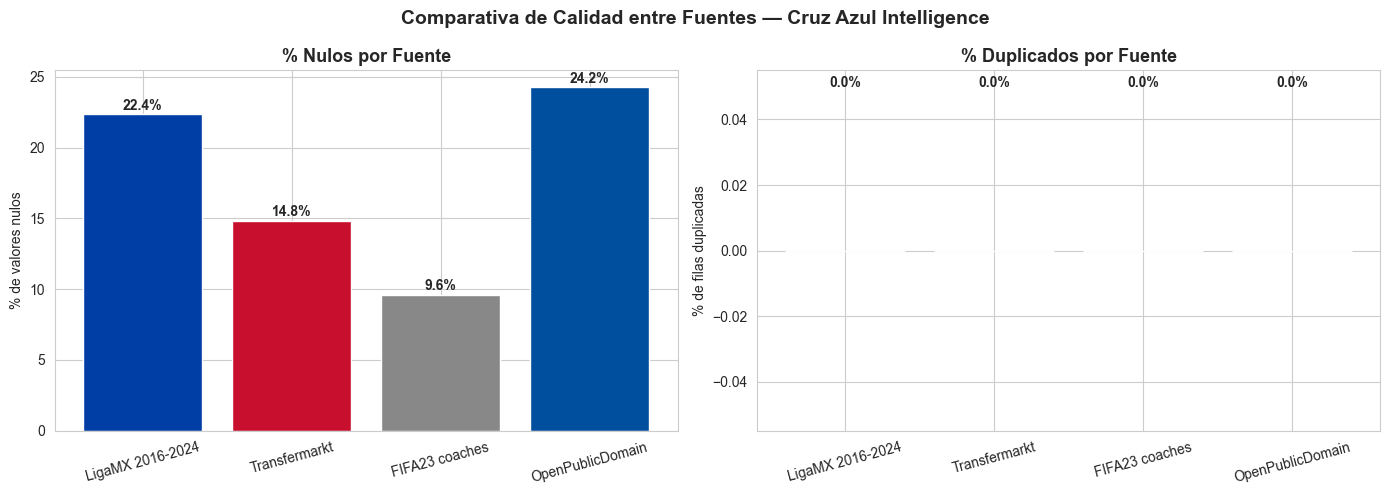

In [38]:
# Grafica comparativa de completitud entre fuentes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# % Nulos por fuente
axes[0].bar(resumen['Fuente'], resumen['Nulos (%)'],
            color=['#003DA5', '#C8102E', '#888888', '#004F9E'])
axes[0].set_title('% Nulos por Fuente', fontweight='bold')
axes[0].set_ylabel('% de valores nulos')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(resumen['Nulos (%)']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# % Duplicados por fuente
axes[1].bar(resumen['Fuente'], resumen['Duplicados (%)'],
            color=['#003DA5', '#C8102E', '#888888', '#004F9E'])
axes[1].set_title('% Duplicados por Fuente', fontweight='bold')
axes[1].set_ylabel('% de filas duplicadas')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(resumen['Duplicados (%)']):
    axes[1].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Comparativa de Calidad entre Fuentes — Cruz Azul Intelligence', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Perfilado Automático con ydata-profiling

Se genera un reporte HTML interactivo por cada fuente con visualizaciones automáticas de distribuciones, correlaciones y alertas de calidad.

In [ ]:
from ydata_profiling import ProfileReport

fuentes = [
    (df_ligamx, 'LigaMX_2016-2024', 'LigaMX — Partidos 2016-2024'),
    (df_tm, 'Transfermarkt_players', 'Transfermarkt — Jugadores'),
    (df_fifa, 'FIFA23_male_coaches', 'FIFA 23 — Entrenadores Masculinos'),
    (df_opfd, 'OpenPublicDomain', 'OpenPublicDomain — Liga MX Histórico'),
]

for df, nombre_archivo, titulo in fuentes:
    print(f'Generando reporte: {titulo} ...')
    reporte = ProfileReport(
        df,
        title=f'Perfilado — {titulo}',
        explorative=True,
        minimal=False)
    ruta_html = os.path.join(REPORTS, f'perfil_{nombre_archivo}.html')
    reporte.to_file(ruta_html)
    print(f'  Guardado: {ruta_html}')

print('\nTodos los reportes generados en la carpeta reports/')

Generando reporte: LigaMX — Partidos 2016-2024 ...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 23/23 [00:00<00:00, 114.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...

100%|██████████| 13/13 [00:00<00:00, 84.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

  Guardado: /Users/milenafer/Desktop/claude/Calidad_PFinal/reports/perfil_OpenPublicDomain.html

Todos los reportes generados en la carpeta reports/


---
## 9. Conclusiones del Perfilado

Resumen de hallazgos por dimensión de calidad DAMA-DMBOK para cada fuente:

In [39]:
conclusiones = {
    'Fuente': ['LigaMX', 'Transfermarkt', 'FIFA 23', 'OpenPublicDomain'],
    'Completitud': [
        'Evaluar % nulos en columnas de goles y árbitros',
        'Valores de mercado faltantes en jugadores de Liga MX (Prob. #2)',
        'Verificar columnas de rating y nacionalidad',
        'Tiempo y zona horaria frecuentemente ausentes'],
    'Consistencia': [
        'Nombres de equipos cambian entre temporadas (Prob. #4)',
        'Nombres de jugadores con múltiples formatos (Prob. #1)',
        'Escalas FIFA 0-100 incomparables con Transfermarkt (Prob. #5)',
        'Nombres de equipos históricos vs actuales (Prob. #4)'],
    'Unicidad': [
        'Revisar partidos duplicados en períodos superpuestos',
        'Jugadores naturalizados con doble registro (Prob. #3)',
        'Entrenadores con variaciones de nombre',
        'Partidos repetidos al concatenar temporadas'],
    'Acción siguiente': [
        'Estandarizar nombres de equipos',
        'Imputar valores de mercado faltantes',
        'Normalizar escalas a rango común',
        'Deduplicar por fecha + equipos']}

df_conclusiones = pd.DataFrame(conclusiones)
display(df_conclusiones.style
    .set_caption('Conclusiones del Perfilado — Acciones para etapa de Limpieza')
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

print('\nSiguiente etapa: limpieza.ipynb')

,Fuente,Completitud,Consistencia,Unicidad,Acción siguiente
0,LigaMX,Evaluar % nulos en columnas de goles y árbitros,Nombres de equipos cambian entre temporadas (Prob. #4),Revisar partidos duplicados en períodos superpuestos,Estandarizar nombres de equipos
1,Transfermarkt,Valores de mercado faltantes en jugadores de Liga MX (Prob. #2),Nombres de jugadores con múltiples formatos (Prob. #1),Jugadores naturalizados con doble registro (Prob. #3),Imputar valores de mercado faltantes
2,FIFA 23,Verificar columnas de rating y nacionalidad,Escalas FIFA 0-100 incomparables con Transfermarkt (Prob. #5),Entrenadores con variaciones de nombre,Normalizar escalas a rango común
3,OpenPublicDomain,Tiempo y zona horaria frecuentemente ausentes,Nombres de equipos históricos vs actuales (Prob. #4),Partidos repetidos al concatenar temporadas,Deduplicar por fecha + equipos



Siguiente etapa: limpieza.ipynb
